# 🔴 미션 3 (선택) — 논문 이후에 실제로 바뀐 것 하나

오늘 우리는 논문 Fig 1 대로 만들었다: **더하고 나서 정규화** — `LayerNorm(x + Sublayer(x))`.
이걸 **Post-LN**(정규화가 뒤) 이라고 부른다.

그런데 요즘 나오는 모델들은 순서를 바꿔 쓴다. **먼저 정규화하고 나서 서브층에 넣는다** —
`x + Sublayer(LayerNorm(x))`. 이걸 **Pre-LN**(정규화가 앞) 이라고 한다.

진짜 그런지 **직접 확인**하고, 왜 바꿨는지 재 본다.

## 낼 것

1. 두 모델의 모듈 순서를 나란히 찍은 화면
2. 한 줄: **"무엇이 달라지나"**

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent if Path.cwd().name == "missions" else Path.cwd()))

import matplotlib.pyplot as plt
import torch
import torch.nn as nn

import block
import koplot

koplot.use_korean()

[koplot] 한글 폰트 적용: Noto Sans KR


'Noto Sans KR'

## 1. 실제 모델 두 개의 블록 속을 열어 본다

BERT 는 이미 받아 놨다. GPT-2 계열은 **설정만 내려받아 구조를 만든다** —
가중치는 안 받으므로 순식간이다 (오늘은 구조만 보면 되니까).

In [2]:
from transformers import AutoConfig, AutoModel
import transformers.utils.logging as hf_logging

hf_logging.set_verbosity_error()

버트 = block.load_bert()
버트블록 = 버트.encoder.layer[0]

지피티설정 = AutoConfig.from_pretrained("skt/kogpt2-base-v2")
지피티 = AutoModel.from_config(지피티설정)     # 구조만. 가중치는 무작위
지피티블록 = 지피티.h[0]

print("BERT (2018) 블록 안의 순서")
print("  ", [이름 for 이름, _ in 버트블록.named_children()])
print("   attention 안:", [이름 for 이름, _ in 버트블록.attention.named_children()])
print("   attention.output 안:", [이름 for 이름, _ in 버트블록.attention.output.named_children()])
print()
print("GPT-2 (2019) 블록 안의 순서")
print("  ", [이름 for 이름, _ in 지피티블록.named_children()])

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/1.00k [00:00<?, ?B/s]

c:\Users\es\.virtualenvs\commonenv\Lib\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\es\.cache\huggingface\hub\models--skt--kogpt2-base-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


BERT (2018) 블록 안의 순서
   ['attention', 'intermediate', 'output']
   attention 안: ['self', 'output']
   attention.output 안: ['dense', 'LayerNorm', 'dropout']

GPT-2 (2019) 블록 안의 순서
   ['ln_1', 'attn', 'ln_2', 'mlp']


### ✍️ 무엇이 다른가 — 직접 읽어 보자

BERT: `attention.output` 안이 `dense` → `LayerNorm` 순서다.
즉 **어텐션을 통과시키고 → 더하고 → 그다음에 정규화**한다. **Post-LN.**

GPT-2: 블록의 첫 모듈이 `ln_1` 이다. 그다음이 `attn`.
즉 **먼저 정규화하고 → 어텐션에 넣는다.** **Pre-LN.**

논문(2017)과 BERT(2018)는 Post-LN 이었는데, GPT-2(2019) 부터 순서가 바뀌었다.

In [3]:
print("파라미터 개수는 어떤가:")
print(f"  BERT  블록 : {block.n_params(버트블록):,}")
print(f"  GPT-2 블록 : {block.n_params(지피티블록):,}")
print("\n→ 순서만 바뀌었을 뿐 부품은 그대로다.")

파라미터 개수는 어떤가:
  BERT  블록 : 7,087,872
  GPT-2 블록 : 7,087,872

→ 순서만 바뀌었을 뿐 부품은 그대로다.


## 2. 순서가 바뀌면 무엇이 달라지나 — 깊게 쌓아서 재 본다

두 방식의 차이는 **잔차 지름길이 정규화를 거치느냐**다.

```
Post-LN :  x  ←  LayerNorm( x + Sublayer(x) )      지름길도 정규화를 통과한다
Pre-LN  :  x  ←  x + Sublayer( LayerNorm(x) )      지름길은 그냥 지나간다
```

파이토치는 이 순서를 `norm_first` 하나로 바꿀 수 있다.

- `norm_first=False` (기본) → **Post-LN**, 논문·BERT 방식
- `norm_first=True` → **Pre-LN**, GPT-2 이후 방식

**먼저 예상해 보자.** 층을 아주 깊게 쌓으면 나오는 값의 크기는 어떻게 될까?

In [4]:
d, d_ff, h = 128, 512, 8
깊이목록 = [2, 6, 12, 24, 48]      # ✍️ 바꿔 본다


def 출력크기(깊이, 먼저정규화):
    """깊이만큼 쌓아 통과시킨 뒤, 나온 값이 얼마나 퍼져 있는지."""
    torch.manual_seed(0)
    층 = nn.TransformerEncoderLayer(
        d_model=d, nhead=h, dim_feedforward=d_ff,
        norm_first=먼저정규화, batch_first=True, dropout=0.0,
    )
    # enable_nested_tensor=False — norm_first=True 일 때 파이토치가 쓸데없는 경고를
    # 하나 뱉는다. 계산 결과와는 상관없고, 경고만 지우는 것이다.
    스택 = nn.TransformerEncoder(층, num_layers=깊이, enable_nested_tensor=False)
    x = torch.randn(1, 8, d)
    with torch.no_grad():
        return 스택(x).std().item()

In [5]:
포스트 = [출력크기(k, False) for k in 깊이목록]
프리 = [출력크기(k, True) for k in 깊이목록]

print(f"{'깊이':>6s} {'Post-LN (논문·BERT)':>22s} {'Pre-LN (GPT-2 이후)':>22s}")
print("-" * 52)
for i, k in enumerate(깊이목록):
    print(f"{k:>6d} {포스트[i]:>22.3f} {프리[i]:>22.3f}")

    깊이      Post-LN (논문·BERT)      Pre-LN (GPT-2 이후)
----------------------------------------------------
     2                  1.000                  1.155
     6                  1.000                  2.001
    12                  1.000                  3.934
    24                  1.000                  8.535
    48                  1.000                 18.998


findfont: Failed to find font weight normal, now using 100.
findfont: Failed to find font weight normal, now using 100.
findfont: Failed to find font weight normal, now using 100.


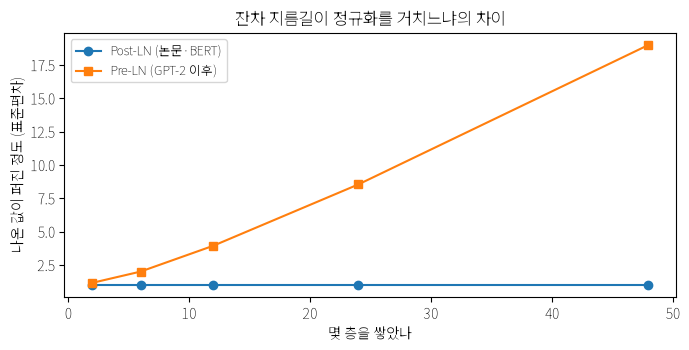

In [6]:
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(깊이목록, 포스트, marker="o", label="Post-LN (논문·BERT)")
ax.plot(깊이목록, 프리, marker="s", label="Pre-LN (GPT-2 이후)")
ax.set_xlabel("몇 층을 쌓았나")
ax.set_ylabel("나온 값이 퍼진 정도 (표준편차)")
ax.set_title("잔차 지름길이 정규화를 거치느냐의 차이")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 3. 무엇을 본 것인가

**Post-LN 은 깊이와 상관없이 크기가 그대로다.** 매 층 마지막에 `LayerNorm` 을 지나므로
나오는 값이 항상 같은 규격으로 맞춰진다.

**Pre-LN 은 깊어질수록 커진다.** `x + Sublayer(LayerNorm(x))` 에서 왼쪽 `x` 는
아무것도 거치지 않고 통과하므로, 층마다 더해진 것이 **계속 쌓인다.**
(그래서 Pre-LN 모델은 스택 **맨 끝에 정규화를 한 번 더** 두는 것이 보통이다 —
GPT-2 의 `ln_f` 가 그것이다.)

In [7]:
print("GPT-2 의 스택 맨 끝:", [이름 for 이름, _ in 지피티.named_children()])
print("→ ln_f 가 마지막에 한 번 더 있다. Pre-LN 이라 필요한 것이다.")

GPT-2 의 스택 맨 끝: ['wte', 'wpe', 'drop', 'h', 'ln_f']
→ ln_f 가 마지막에 한 번 더 있다. Pre-LN 이라 필요한 것이다.


### ⚠️ 여기서 멈춘다 — "어느 쪽이 낫다"는 오늘 코드로 말할 수 없다

Pre-LN 이 요즘 널리 쓰이는 이유로 흔히 *"깊은 모델을 학습시키기 쉬워서"* 라고 한다.
그건 **학습을 시켜 봐야 아는 것**이고, 오늘 우리는 학습을 하지 않았다.

오늘 확인한 것은 딱 하나 — **순서가 다르고, 그래서 값의 크기가 다르게 움직인다.**
그 이상은 오늘 코드의 근거를 넘어선다.

> BERT 는 Post-LN 으로 아주 잘 학습됐다. **틀린 방식이 아니다.**

## ✍️ 제출 — 한 줄로 적는다

> 논문·BERT 는 ____-LN 이고 GPT-2 이후는 ____-LN 이다.
> 깊게 쌓았을 때 ____ 쪽은 값의 크기가 그대로였고, ____ 쪽은 계속 커졌다.

> ⚠️ 여기 숫자는 무작위 가중치로 잰 것이라 기계마다 다르다.
> 봐야 할 것은 **한쪽은 평평하고 한쪽은 올라간다**는 것이다.